# Macro-activit?s des entreprises ? Caoutchouc, chimie et plasturgie



## Objectif et principe

Le fichier source contient deux syst?mes de codification : les codes ant?rieurs ? 2015 sont des **codes risque historiques** et les codes plus r?cents des **codes APE/NAF**. Ils ne sont donc pas ramen?s artificiellement ? une division NAF commune.

Chaque accident re?oit trois variables de tra?abilit? : `company_code`, `company_label` et `coding_system`. Comme ce fichier ne contient pas la date de l'accident, `coding_system` est identifi? par la forme du code : `123AB` est class? `historical_risk_code` et `1234A` est class? `NAF_APE`. La variable `macro_activity` est ensuite construite ? partir du **libell? d'activit?**, au moyen de r?gles explicites et ordonn?es. Elle forme une taxonomie analytique commune aux deux syst?mes, pens?e pour obtenir des contextes professionnels homog?nes et interpr?tables pour la d?couverte locale de motifs.

Les familles comptant au moins `MIN_CANDIDATE_SIZE` accidents sont des candidates ? l'analyse locale. Les autres sont conserv?es dans `macro_activity_raw`, mais leur `macro_activity` est fix?e ? `Other activities`. Chaque ligne export?e conserve `accident_id`, le code, le libell?, le syst?me, la r?gle appliqu?e et la famille finale.


In [7]:
from pathlib import Path
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

DATASET = "caou"
DATA_PATH = Path("data/caou_chimie_plas_sentence_accidents.csv")
EXPORT_PATH = Path("../dataset/company_family_caou.csv")
MIN_CANDIDATE_SIZE = 20
TAXONOMY_VERSION = "label_based_macro_activity_v1"


In [8]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

sentences = pd.read_csv(DATA_PATH, dtype={"accident_id": "string", "company_code": "string"})
required_columns = {"accident_id", "company_code"}
missing_columns = required_columns.difference(sentences.columns)
if missing_columns:
    raise ValueError(f"Colonnes absentes : {sorted(missing_columns)}")

company_values = sentences.assign(company_code=sentences["company_code"].astype("string").str.strip())
company_values["company_code"] = company_values["company_code"].replace("", pd.NA)
conflicts = company_values.groupby("accident_id", dropna=False)["company_code"].nunique(dropna=True)
if conflicts.gt(1).any():
    raise ValueError("Au moins un accident poss?de plusieurs codes entreprise distincts.")

accidents = (
    company_values.groupby("accident_id", as_index=False, dropna=False)["company_code"]
    .agg(lambda values: values.dropna().iloc[0] if not values.dropna().empty else pd.NA)
    .rename(columns={"company_code": "company_code_raw"})
)
print(f"{DATASET}: {len(accidents):,} accidents uniques")


caou: 838 accidents uniques


In [9]:
TAXONOMY_RULES = (
    ("plastics_manufacturing", "Plastics manufacturing", r"plastique|mati.re plastique|polym"),
    ("rubber_manufacturing", "Rubber manufacturing", r"caoutchouc"),
    ("pharmaceutical_manufacturing", "Pharmaceutical manufacturing", r"pharm|m.dicament|sp.cialit.s pharm"),
    ("chemical_products_manufacturing", "Chemicals and chemical products", r"chimie|chimique|peinture|vernis|encres|d.tergent|savon|produits d entretien|explosif|pyrotech|colles|g.latine|acide|chlorure|soude|pigment|alcool|gaz industriels|huiles et corps raffin"),
    ("food_manufacturing", "Food manufacturing", r"aliment|boisson|viande|lait|sucre|p.tisserie|conserverie"),
)


parsed = accidents["company_code_raw"].astype("string").str.extract(
    r"^\s*(?P<company_code>(?:\d{4}[A-Z]|\d{3}[A-Z]{2}))\s*-\s*(?P<company_label>.+?)\s*$"
)
accidents["company_code"] = parsed["company_code"].astype("string")
accidents["company_label"] = parsed["company_label"].astype("string")

# La forme du code distingue les syst?mes, sans supposer de correspondance entre eux.
accidents["coding_system"] = pd.Series("unclassified", index=accidents.index, dtype="string")
accidents.loc[accidents["company_code"].str.fullmatch(r"\d{3}[A-Z]{2}").fillna(False), "coding_system"] = "historical_risk_code"
accidents.loc[accidents["company_code"].str.fullmatch(r"\d{4}[A-Z]").fillna(False), "coding_system"] = "NAF_APE"


def assign_macro_activity(label: object) -> tuple[str, str]:
    if pd.isna(label):
        return "Other activities", "missing_or_unparseable_label"
    label_text = str(label).lower()
    for rule_id, macro_activity, pattern in TAXONOMY_RULES:
        if re.search(pattern, label_text):
            return macro_activity, rule_id
    return "Other activities", "no_taxonomy_rule_matched"

assignments = accidents["company_label"].map(assign_macro_activity)
accidents[["macro_activity_raw", "macro_activity_rule"]] = pd.DataFrame(
    assignments.tolist(), index=accidents.index
)
accidents["macro_activity_raw"] = accidents["macro_activity_raw"].astype("string")
accidents["macro_activity_rule"] = accidents["macro_activity_rule"].astype("string")

raw_counts = accidents["macro_activity_raw"].value_counts()
accidents["macro_activity_size_before_other"] = accidents["macro_activity_raw"].map(raw_counts).astype("Int64")
accidents["macro_activity"] = accidents["macro_activity_raw"].copy()
small_or_other = (
    accidents["macro_activity_raw"].eq("Other activities")
    | accidents["macro_activity_size_before_other"].lt(MIN_CANDIDATE_SIZE)
)
accidents.loc[small_or_other, "macro_activity"] = "Other activities"
accidents["is_local_analysis_candidate"] = ~accidents["macro_activity"].eq("Other activities")
accidents["family"] = accidents["macro_activity"]
accidents["family_grouping_reason"] = pd.Series(
    "Rule applied to company_label: " + accidents["macro_activity_rule"],
    index=accidents.index,
    dtype="string",
)
accidents.loc[small_or_other, "family_grouping_reason"] = (
    "Other activities: raw macro-activity is unmatched or below "
    + str(MIN_CANDIDATE_SIZE)
    + " accidents; raw assignment retained in macro_activity_raw."
)
accidents["taxonomy_version"] = TAXONOMY_VERSION


In [10]:
def distribution(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    table = frame[column].fillna("Not recorded").value_counts(dropna=False).rename_axis(column).reset_index(name="n_accidents")
    table["part_pct"] = (100 * table["n_accidents"] / len(frame)).round(1)
    return table

summary = pd.DataFrame([{
    "dataset": DATASET,
    "n_accidents": len(accidents),
    "n_historical_risk_code": int(accidents["coding_system"].eq("historical_risk_code").sum()),
    "n_NAF_APE": int(accidents["coding_system"].eq("NAF_APE").sum()),
    "n_local_analysis_candidates": int(accidents["is_local_analysis_candidate"].sum()),
    "n_candidate_macro_activities": int(accidents.loc[accidents["is_local_analysis_candidate"], "macro_activity"].nunique()),
    "minimum_candidate_size": MIN_CANDIDATE_SIZE,
}])
macro_distribution = distribution(accidents, "macro_activity")
raw_macro_distribution = distribution(accidents, "macro_activity_raw")
coding_system_distribution = distribution(accidents, "coding_system")
rule_audit = (
    accidents.groupby(["macro_activity_rule", "macro_activity_raw"], dropna=False)
    .agg(n_accidents=("accident_id", "size"), n_company_codes=("company_code", "nunique"))
    .reset_index()
    .sort_values("n_accidents", ascending=False, kind="stable")
)

print("Summary")
display(summary)
print("Macro-activity distribution")
display(macro_distribution)
print("Mapping-rule audit")
display(rule_audit)


Summary


,dataset,n_accidents,n_historical_risk_code,n_NAF_APE,n_local_analysis_candidates,n_candidate_macro_activities,minimum_candidate_size
0,caou,838,725,113,722,4,20


Macro-activity distribution


,macro_activity,n_accidents,part_pct
0,Plastics manufacturing,333,39.7
1,Chemicals and chemical products,232,27.7
2,Other activities,116,13.8
3,Rubber manufacturing,96,11.5
4,Pharmaceutical manufacturing,61,7.3


Mapping-rule audit


,macro_activity_rule,macro_activity_raw,n_accidents,n_company_codes
3,plastics_manufacturing,Plastics manufacturing,333,7
0,chemical_products_manufacturing,Chemicals and chemical products,232,16
1,no_taxonomy_rule_matched,Other activities,116,33
4,rubber_manufacturing,Rubber manufacturing,96,3
2,pharmaceutical_manufacturing,Pharmaceutical manufacturing,61,4


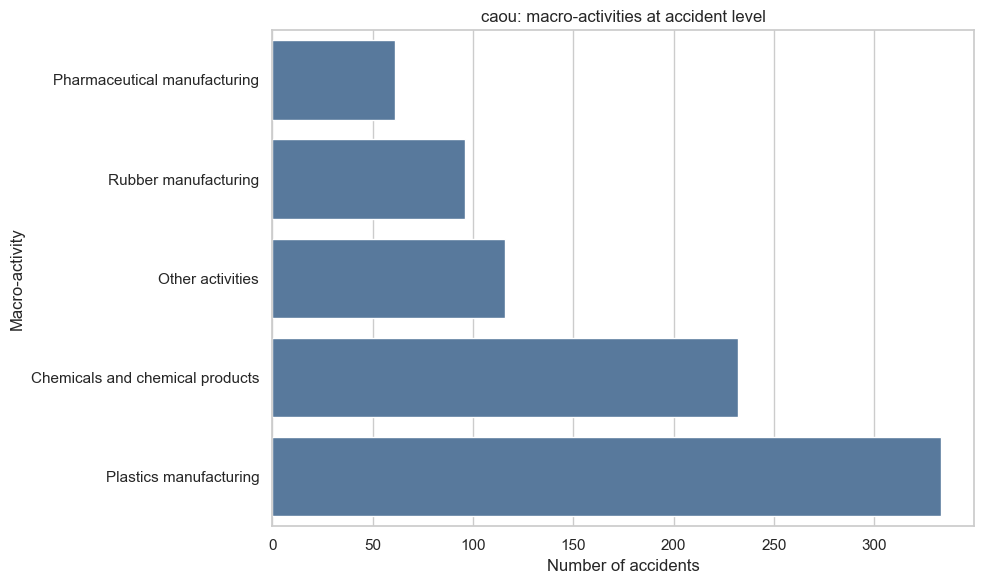

In [11]:
sns.set_theme(style="whitegrid")
plot_data = macro_distribution.sort_values("n_accidents", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_data, y="macro_activity", x="n_accidents", color="#4C78A8", ax=ax)
ax.set_title(f"{DATASET}: macro-activities at accident level")
ax.set_xlabel("Number of accidents")
ax.set_ylabel("Macro-activity")
plt.tight_layout()
plt.show()


## Audit de la taxonomie

Les r?gles de la cellule de classification sont volontairement visibles et appliqu?es dans l'ordre indiqu?. Le tableau `rule_audit` donne leur effectif. Les lignes sans r?gle, ainsi que les familles sous le seuil, restent dans `Other activities`; leur affectation initiale demeure disponible dans `macro_activity_raw` pour contr?le expert et r?vision de la taxonomie.


In [12]:
export_columns = [
    "accident_id",
    "company_code_raw",
    "company_code",
    "company_label",
    "coding_system",
    "macro_activity_raw",
    "macro_activity_rule",
    "macro_activity_size_before_other",
    "macro_activity",
    "is_local_analysis_candidate",
    "family",
    "family_grouping_reason",
    "taxonomy_version",
]
family_export = accidents[export_columns].sort_values("accident_id", kind="stable")
if not family_export["accident_id"].is_unique:
    raise AssertionError("The export must contain one row per accident_id.")
EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
family_export.to_csv(EXPORT_PATH, index=False)
print(f"Export written: {EXPORT_PATH.resolve()}")
display(family_export.head())

# Example join:
# dataset = pd.read_csv(Path(f"../dataset/data_{DATASET}.csv"), dtype={"accident_id": "string"})
# dataset_with_family = dataset.merge(family_export[["accident_id", "family"]], on="accident_id", how="left")


Export written: C:\Users\aho\Documents\analysis factor project\SAFER\text\dataset\company_family_caou.csv


,accident_id,company_code_raw,company_code,company_label,coding_system,macro_activity_raw,macro_activity_rule,macro_activity_size_before_other,macro_activity,is_local_analysis_candidate,family,family_grouping_reason,taxonomy_version
0,0002C7DF2B16600EC125719D005318FB,"243ZC - Huiles et corps raffinés d'origine animale et végétale. Fabrication de peinture, vernis, couleurs fines et encres d'imprimerie, de produits de ménage et d'entretien, de produits savonniers, de produits explosifs, d'engins et accessoires pyrotechniques, de colles, de gélatine d'origine animal et liquides à base de matière amylacées",243ZC,"Huiles et corps raffinés d'origine animale et végétale. Fabrication de peinture, vernis, couleurs fines et encres d'imprimerie, de produits de ménage et d'entretien, de produits savonniers, de produits explosifs, d'engins et accessoires pyrotechniques, de colles, de gélatine d'origine animal et liquides à base de matière amylacées",historical_risk_code,Chemicals and chemical products,chemical_products_manufacturing,232,Chemicals and chemical products,True,Chemicals and chemical products,Rule applied to company_label: chemical_products_manufacturing,label_based_macro_activity_v1
1,00A218F2355F4D0AC125719D0053A125,"241GM - Chimie organique de synthèse (de produits non désignés ailleurs). Fabrication de pigments minéraux, de compositions de base de pigments, de compositions et couleurs vitrifiables pour émaux, de chlorure / soude électrolytique, lessive soude électrolytique, de chlorure / sodium (électrolyse ignée), de charbons actifs pour filtres, de noir animal, de charbon animal, d'acide sulfurique et dérivés, de produits minéraux divers, d'acide tartrique, citrique et dérivé, de papier carbone, stencils. Salines ignigènes. Dénaturation d'alcool éthylique",241GM,"Chimie organique de synthèse (de produits non désignés ailleurs). Fabrication de pigments minéraux, de compositions de base de pigments, de compositions et couleurs vitrifiables pour émaux, de chlorure / soude électrolytique, lessive soude électrolytique, de chlorure / sodium (électrolyse ignée), de charbons actifs pour filtres, de noir animal, de charbon animal, d'acide sulfurique et dérivés, de produits minéraux divers, d'acide tartrique, citrique et dérivé, de papier carbone, stencils. Salines ignigènes. Dénaturation d'alcool éthylique",historical_risk_code,Chemicals and chemical products,chemical_products_manufacturing,232,Chemicals and chemical products,True,Chemicals and chemical products,Rule applied to company_label: chemical_products_manufacturing,label_based_macro_activity_v1
2,00E80ADDCFD63445C125719D0053986A,"154AD - Fabrication de matières colorantes de synthèse. Fabrication électrolytique de chlore, de potasse caustique, de chlorate et perchlorate, de fluor, d'acide fluorhydrique, de brome, d'acide bromohydrique, d'huile et de corps gras d'origine végétale et animale; d'engrais phosphatés, d'autres engrais minéraux et organiques, de produits nologiques",154AD,"Fabrication de matières colorantes de synthèse. Fabrication électrolytique de chlore, de potasse caustique, de chlorate et perchlorate, de fluor, d'acide fluorhydrique, de brome, d'acide bromohydrique, d'huile et de corps gras d'origine végétale et animale; d'engrais phosphatés, d'autres engrais minéraux et organiques, de produits nologiques",historical_risk_code,Chemicals and chemical products,chemical_products_manufacturing,232,Chemicals and chemical products,True,Chemicals and chemical products,Rule applied to company_label: chemical_products_manufacturing,label_based_macro_activity_v1
3,01D96B31E8FFFC05C1258AAD005332CC,"2221Z - Fabrication de plaques, feuilles, tubes et profilés en matières plastiques",2221Z,"Fabrication de plaques, feuilles, tubes et profilés en matières plastiques",NAF_APE,Plastics manufacturing,plastics_manufacturing,333,Plastics manufacturing,True,Plastics manufacturing,Rule applied to company_label: plastics_manufacturing,label_based_macro_activity_v1
4,0264EE63C61

## Export des sous-corpus pour le topic modeling

Cette cellule cr?e un couple unit?s?embeddings par macro-activit? candidate. Les vecteurs existants sont filtr?s par `fact_id`/`doc_id` ; aucun r?-encodage n?est effectu?.


In [13]:
# Build topic-modeling inputs for selected macro-activity families.
# The generated unit and embedding files remain aligned through fact_id / doc_id.
# Re-run this cell after changing the taxonomy or the threshold above.

FAMILIES_TO_EXPORT = None  # None = all local-analysis candidates; or e.g. ["Metal forming and fabrication"]
INCLUDE_OTHER_ACTIVITIES = False
SOURCE_UNITS_PATH = Path(f"../dataset/data_{DATASET}.csv")
SOURCE_EMBEDDINGS_PATH = Path(f"../embeddings/Qwen3-Embedding-0.6B_{DATASET}.csv")
FAMILY_DATASET_DIR = Path(f"../dataset/families/{DATASET}")
FAMILY_EMBEDDING_DIR = Path(f"../embeddings/families/{DATASET}")

if not SOURCE_UNITS_PATH.is_file() or not SOURCE_EMBEDDINGS_PATH.is_file():
    raise FileNotFoundError("Source units or embeddings file is missing.")


def is_true(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin({"1", "true", "yes", "y", "t"})


def corpus_slug(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


selected_families = sorted(
    family_export.loc[family_export["is_local_analysis_candidate"], "macro_activity"].dropna().unique().tolist()
)
if INCLUDE_OTHER_ACTIVITIES:
    selected_families.append("Other activities")
if FAMILIES_TO_EXPORT is not None:
    requested = set(FAMILIES_TO_EXPORT)
    unknown = requested.difference(selected_families)
    if unknown:
        raise ValueError(f"Unknown or ineligible families: {sorted(unknown)}")
    selected_families = [family for family in selected_families if family in requested]
if not selected_families:
    raise ValueError("No family selected for export.")

units_source = pd.read_csv(SOURCE_UNITS_PATH, dtype={"accident_id": "string", "fact_id": "string"})
required_unit_columns = {"accident_id", "fact_id", "sentence", "pred_label"}
missing_unit_columns = required_unit_columns.difference(units_source.columns)
if missing_unit_columns:
    raise ValueError(f"Missing unit columns: {sorted(missing_unit_columns)}")

family_lookup = family_export[["accident_id", "macro_activity", "family", "is_local_analysis_candidate"]].copy()
family_lookup["accident_id"] = family_lookup["accident_id"].astype("string")
units_source["accident_id"] = units_source["accident_id"].astype("string")
units_source["fact_id"] = units_source["fact_id"].astype("string")
units_with_family = units_source.merge(family_lookup, on="accident_id", how="inner", validate="many_to_one")

# Match the exact filtering performed by recurrent_scenarios.load_units.
ready_mask = units_with_family["sentence"].fillna("").astype(str).str.strip().ne("")
ready_mask &= units_with_family["pred_label"].astype(str).str.strip().isin({"A0", "A1", "B", "C"})
if "pred_ok" in units_with_family.columns:
    ready_mask &= is_true(units_with_family["pred_ok"])
topic_ready_units = units_with_family.loc[ready_mask].copy()
if topic_ready_units["fact_id"].duplicated().any():
    raise ValueError("fact_id must be unique after topic-input filtering.")

embeddings_source = pd.read_csv(SOURCE_EMBEDDINGS_PATH, dtype={"doc_id": "string"})
if "doc_id" not in embeddings_source.columns:
    raise ValueError("Embeddings must contain doc_id.")
if embeddings_source["doc_id"].duplicated().any():
    raise ValueError("Embedding doc_id must be unique.")

FAMILY_DATASET_DIR.mkdir(parents=True, exist_ok=True)
FAMILY_EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
manifest_rows = []
for family in selected_families:
    corpus_id = f"{DATASET}_{corpus_slug(family)}"
    family_units = topic_ready_units.loc[topic_ready_units["macro_activity"].eq(family)].copy()
    fact_ids = family_units["fact_id"].astype("string")
    family_embeddings = embeddings_source.loc[embeddings_source["doc_id"].isin(fact_ids)].copy()

    missing_embeddings = set(fact_ids).difference(set(family_embeddings["doc_id"]))
    if missing_embeddings:
        raise ValueError(f"{corpus_id}: {len(missing_embeddings)} units have no embedding.")
    if len(family_embeddings) != len(family_units):
        raise ValueError(f"{corpus_id}: units / embeddings row count mismatch.")

    units_path = FAMILY_DATASET_DIR / f"data_{corpus_id}.csv"
    embeddings_path = FAMILY_EMBEDDING_DIR / f"Qwen3-Embedding-0.6B_{corpus_id}.csv"
    family_units.to_csv(units_path, index=False)
    family_embeddings.to_csv(embeddings_path, index=False)
    manifest_rows.append({
        "dataset_id": corpus_id,
        "macro_activity": family,
        "n_accidents": int(family_units["accident_id"].nunique()),
        "n_units": int(len(family_units)),
        "n_embeddings": int(len(family_embeddings)),
        "units_path": str(units_path),
        "embeddings_path": str(embeddings_path),
    })

family_topic_manifest = pd.DataFrame(manifest_rows).sort_values("dataset_id", kind="stable")
manifest_path = FAMILY_DATASET_DIR / "topic_modeling_manifest.csv"
family_topic_manifest.to_csv(manifest_path, index=False)
display(family_topic_manifest)
print(f"Manifest written: {manifest_path.resolve()}")
print("Use one dataset_id with: DATASET=<dataset_id> sbatch jobs/run_recurrent_scenarios_theme_discovery.sh")


,dataset_id,macro_activity,n_accidents,n_units,n_embeddings,units_path,embeddings_path
0,caou_chemicals_and_chemical_products,Chemicals and chemical products,232,1619,1619,..\dataset\families\caou\data_caou_chemicals_and_chemical_products.csv,..\embeddings\families\caou\Qwen3-Embedding-0.6B_caou_chemicals_and_chemical_products.csv
1,caou_pharmaceutical_manufacturing,Pharmaceutical manufacturing,61,404,404,..\dataset\families\caou\data_caou_pharmaceutical_manufacturing.csv,..\embeddings\families\caou\Qwen3-Embedding-0.6B_caou_pharmaceutical_manufacturing.csv
2,caou_plastics_manufacturing,Plastics manufacturing,333,2414,2414,..\dataset\families\caou\data_caou_plastics_manufacturing.csv,..\embeddings\families\caou\Qwen3-Embedding-0.6B_caou_plastics_manufacturing.csv
3,caou_rubber_manufacturing,Rubber manufacturing,96,665,665,..\dataset\families\caou\data_caou_rubber_manufacturing.csv,..\embeddings\families\caou\Qwen3-Embedding-0.6B_caou_rubber_manufacturing.csv


Manifest written: C:\Users\aho\Documents\analysis factor project\SAFER\text\dataset\families\caou\topic_modeling_manifest.csv
Use one dataset_id with: DATASET=<dataset_id> sbatch jobs/run_recurrent_scenarios_theme_discovery.sh
